In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from xgboost import XGBRegressor

In [2]:
X_train = pd.read_csv("../data/processed/X_train_v16.csv")
X_test = pd.read_csv("../data/processed/X_test_v16.csv")

y_train = pd.read_csv("../data/processed/y_train_v16.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test_v16.csv").squeeze()

In [3]:
xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [4]:
baseline_lst = xgb.predict(
    X_test
)

In [21]:
# Identify hottest 10% of locations

hotspots = baseline_lst > np.percentile(
    baseline_lst,
    90
)

print(
    "Number of hotspot cells:",
    hotspots.sum()
)

Number of hotspot cells: 639


In [ ]:
green_targeted = X_test.copy()

green_targeted.loc[
    hotspots,
    "mean_ndvi"
] += 0.05

In [ ]:
green_targeted["mean_ndvi"] = green_targeted[
    "mean_ndvi"
].clip(
    upper=1
)

In [ ]:
green_targeted_lst = xgb.predict(
    green_targeted
)

green_targeted_cooling = (
    baseline_lst -
    green_targeted_lst
)

In [8]:
green_cooling = baseline_lst - green_lst

In [9]:
print(
    "Average cooling:",
    green_cooling.mean()
)

print(
    "Maximum cooling:",
    green_cooling.max()
)

Average cooling: 8.0621805
Maximum cooling: 20.88553


In [10]:
roof = X_test.copy()

roof["mean_albedo"] += 0.05

In [11]:
roof["mean_albedo"] = roof[
    "mean_albedo"
].clip(upper=1)

In [12]:
roof_lst = xgb.predict(
    roof
)

roof_cooling = baseline_lst - roof_lst

In [13]:
print(
    roof_cooling.mean()
)

print(
    roof_cooling.max()
)

6.1097884
18.69714


In [14]:
combined = X_test.copy()

combined["mean_ndvi"] += 0.05

combined["mean_albedo"] += 0.05

In [15]:
combined["mean_ndvi"] = combined[
    "mean_ndvi"
].clip(upper=1)

combined["mean_albedo"] = combined[
    "mean_albedo"
].clip(upper=1)

In [16]:
combined_lst = xgb.predict(
    combined
)

combined_cooling = (
    baseline_lst -
    combined_lst
)

In [17]:
print(
    combined_cooling.mean()
)

print(
    combined_cooling.max()
)

14.670833
29.216734


In [18]:
results = pd.DataFrame(
    {
        "Intervention": [
            "Greening",
            "Cool Roofs",
            "Combined"
        ],

        "Average Cooling": [
            green_cooling.mean(),
            roof_cooling.mean(),
            combined_cooling.mean()
        ],

        "Maximum Cooling": [
            green_cooling.max(),
            roof_cooling.max(),
            combined_cooling.max()
        ]
    }
)

results

,Intervention,Average Cooling,Maximum Cooling
0,Greening,8.062181,20.885530
1,Cool Roofs,6.109788,18.697140
2,Combined,14.670833,29.216734


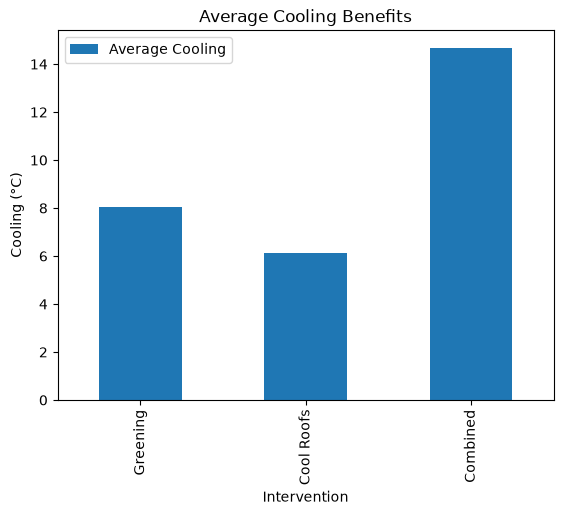

In [19]:
results.plot(
    x="Intervention",
    y="Average Cooling",
    kind="bar"
)

plt.ylabel(
    "Cooling (°C)"
)

plt.title(
    "Average Cooling Benefits"
)

plt.show()

In [20]:
print(
    "Baseline LST:",
    baseline_lst.mean()
)

print(
    "Greening reduction (%):",
    100 * green_cooling.mean() / baseline_lst.mean()
)

print(
    "Cool roof reduction (%):",
    100 * roof_cooling.mean() / baseline_lst.mean()
)

print(
    "Combined reduction (%):",
    100 * combined_cooling.mean() / baseline_lst.mean()
)

Baseline LST: 42.638092
Greening reduction (%): 18.9084
Cool roof reduction (%): 14.329412
Combined reduction (%): 34.407806
